# 02 — Displacement Research

## Purpose
Understand what a 'displacement' looks like in real XAUUSDT data,
and find the optimal parameters for detecting institutional moves.

## What this notebook covers
1. Visualize displacement patterns on real M5 data
2. Parameter sensitivity: min_candles (3–8) and ATR multiplier (1.0–3.0)
3. Count how many OBs each parameter set produces
4. Identify the sweet spot: enough signals to trade, few enough to be selective

## Key questions
- What is the average displacement size in XAUUSDT M5?
- Does requiring more candles filter bad OBs or just reduce trade frequency?
- Is ATR 1.5× a good threshold or should we use 2.0× for crypto?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from strategy.ob_core import add_candle_features, _detect_displacements, _find_order_blocks

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 7)})

SYMBOL = 'XAUUSDT'
m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = m5.sort_index()

# Add candle features (ATR, body, wicks)
m5 = add_candle_features(m5)
print(f'Loaded {len(m5):,} M5 bars  |  ATR mean={m5["atr"].mean():.2f}')

Loaded 19,798 M5 bars  |  ATR mean=4.44


In [2]:
# ── Parameter sensitivity sweep ────────────────────────────────────────────
min_candles_range = [3, 4, 5, 6, 7, 8]
atr_mult_range    = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5]

results = []
for min_c in min_candles_range:
    for atr_m in atr_mult_range:
        disps = _detect_displacements(m5, min_candles=min_c, atr_mult=atr_m)
        obs   = _find_order_blocks(m5, disps)
        results.append({
            'min_candles'  : min_c,
            'atr_mult'     : atr_m,
            'displacements': len(disps),
            'order_blocks' : len(obs),
        })

sensitivity = pd.DataFrame(results)

# Pivot for heatmap
pivot = sensitivity.pivot(index='min_candles', columns='atr_mult', values='order_blocks')
print('Order Block count by parameter combination:')
print(pivot)

Order Block count by parameter combination:
atr_mult      1.0   1.2   1.5   1.8   2.0  2.5
min_candles                                   
3            2006  1859  1604  1332  1171  814
4            1032   993   930   829   763  582
5             487   484   470   445   428  355
6             233   233   230   224   217  191
7             107   107   106   105   105  100
8              56    56    56    56    56   52


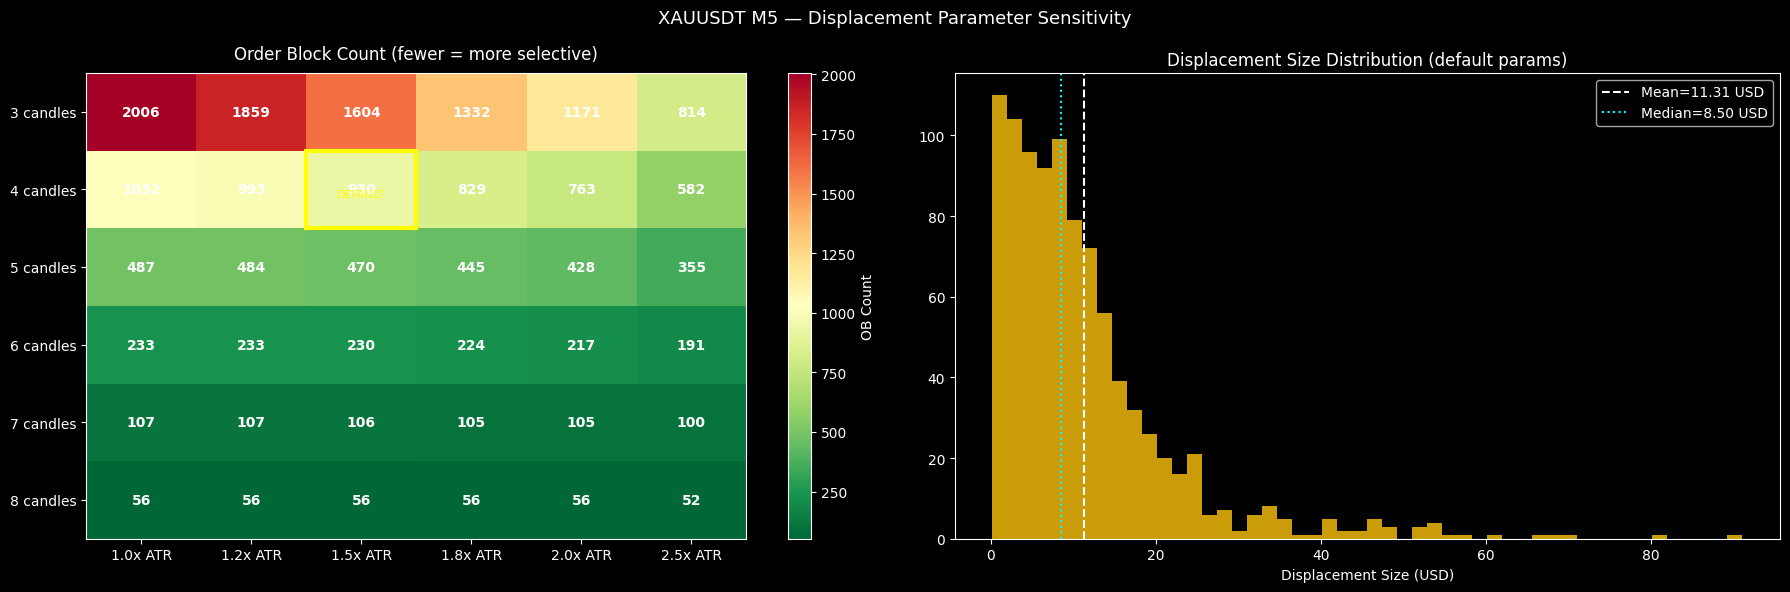


With default params (min_candles=4, atr_mult=1.5):
  Displacements : 930
  Move mean     : 11.31 USD
  Move std      : 10.96 USD


In [3]:
# ── Heatmap visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn_r  # green = few OBs (selective), red = too many

im = axes[0].imshow(pivot.values, cmap=cmap, aspect='auto')
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_xticklabels([f'{v}x ATR' for v in pivot.columns])
axes[0].set_yticklabels([f'{v} candles' for v in pivot.index])
axes[0].set_title('Order Block Count (fewer = more selective)', pad=10)
plt.colorbar(im, ax=axes[0], label='OB Count')

# Annotate cells with values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes[0].text(j, i, str(pivot.values[i, j]), ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')

# Mark current default (min_candles=4, atr_mult=1.5)
axes[0].add_patch(plt.Rectangle((2-0.5, 1-0.5), 1, 1, fill=False, edgecolor='yellow', lw=3))
axes[0].text(2, 1, 'DEFAULT', ha='center', va='top', color='yellow', fontsize=8)

# Distribution of displacement sizes
disps_default = _detect_displacements(m5, min_candles=4, atr_mult=1.5)

# Compute move size for each displacement
moves = []
for d in disps_default:
    seg = m5.iloc[d.start_idx : d.start_idx + 4]
    if len(seg) > 0:
        move = abs(seg['close'].iloc[-1] - seg['open'].iloc[0])
        moves.append(move)

axes[1].hist(moves, bins=50, color='#F0B90B', edgecolor='none', alpha=0.85)
axes[1].axvline(np.mean(moves), color='white', linestyle='--',
                label=f'Mean={np.mean(moves):.2f} USD')
axes[1].axvline(np.median(moves), color='cyan', linestyle=':',
                label=f'Median={np.median(moves):.2f} USD')
axes[1].set_title('Displacement Size Distribution (default params)')
axes[1].set_xlabel('Displacement Size (USD)')
axes[1].legend()

plt.suptitle(f'{SYMBOL} M5 — Displacement Parameter Sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nWith default params (min_candles=4, atr_mult=1.5):')
print(f'  Displacements : {len(disps_default)}')
print(f'  Move mean     : {np.mean(moves):.2f} USD')
print(f'  Move std      : {np.std(moves):.2f} USD')

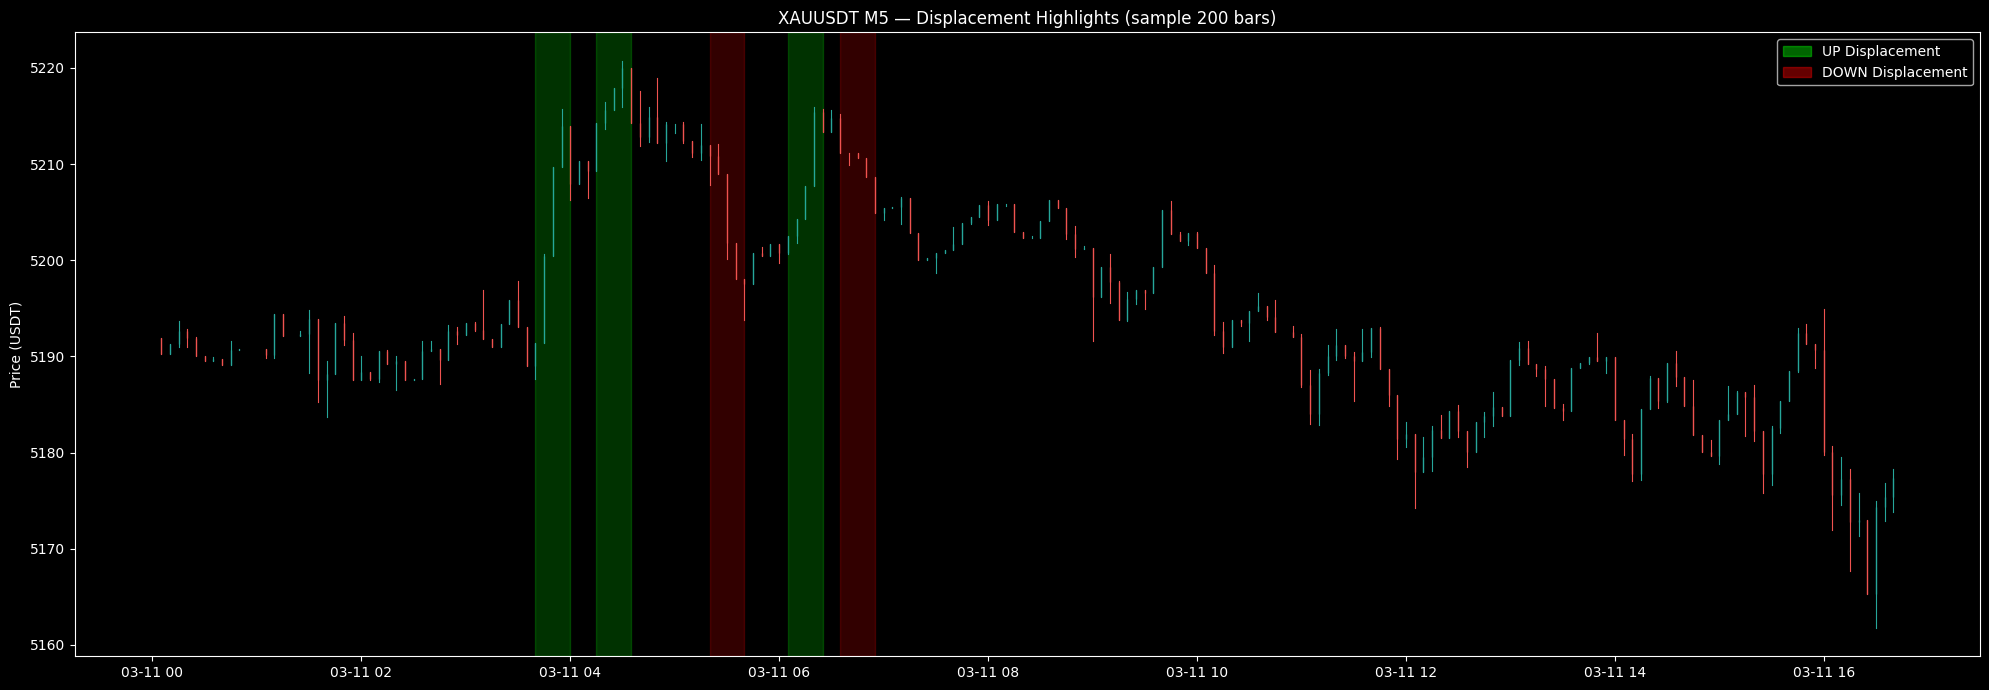

In [4]:
# ── Visualize a sample displacement on a candlestick chart ────────────────
# Show the first 3 displacements on a 200-bar chart
sample_start = 500
sample_end   = 700
sample_m5    = m5.iloc[sample_start:sample_end]
sample_disps = _detect_displacements(sample_m5, min_candles=4, atr_mult=1.5)

fig, ax = plt.subplots(figsize=(20, 7))

# Simple OHLC plot (use body boxes)
for i, (ts, row) in enumerate(sample_m5.iterrows()):
    color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
    ax.plot([ts, ts], [row['low'], row['high']], color=color, linewidth=0.8)
    ax.fill_between([ts], [row['open']], [row['close']],
                    color=color, alpha=0.8)

# Highlight displacement regions
for d in sample_disps[:5]:
    t_start = sample_m5.index[d.start_idx]
    t_end   = sample_m5.index[min(d.start_idx + 4, len(sample_m5) - 1)]
    color   = 'lime' if d.direction == 'UP' else 'red'
    ax.axvspan(t_start, t_end, alpha=0.2, color=color,
               label=f'{d.direction} displacement')

ax.set_title(f'{SYMBOL} M5 — Displacement Highlights (sample 200 bars)')
ax.set_ylabel('Price (USDT)')

handles = [
    mpatches.Patch(color='lime', alpha=0.4, label='UP Displacement'),
    mpatches.Patch(color='red',  alpha=0.4, label='DOWN Displacement'),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

## Conclusions

After this analysis, decide:
- Are 4 candles + 1.5× ATR producing too many/too few displacements?
- Does tightening to 5 candles + 1.8× ATR reduce bad signals?
- Record findings and update `ob_core.py` constants if justified by data.